# **Automated Climate Finance Data Pipeline: Expanding Public Data Sources Using Web Scraping and Python.**

# **Introduction:**

This project develops an automated data pipeline to expand publicly available climate-related datasets using Python-based web scraping techniques.

The objective is to demonstrate how external data sources can be programmatically identified, extracted, and integrated into structured datasets for analysis. By scraping publicly available climate and emissions data, the project simulates real-world workflows used in climate data tracking and reporting.

This approach supports improved data coverage, transparency, and timeliness, which are critical for informing climate finance decisions, policy analysis, and monitoring progress toward net zero targets.

# **Methodology**

This project follows a structured data engineering and analysis pipeline:

1. Data Collection (Web Scraping)
- Retrieved climate-related data from publicly available web sources using Python libraries (requests, BeautifulSoup, pandas)
- Identified relevant tables containing country-level emissions data

2. Data Extraction
- Parsed HTML content and extracted structured tabular data
- Converted scraped data into a pandas DataFrame for further processing

3. Data Cleaning
- Removed unnecessary columns and handled missing values
- Standardised column names and formats for consistency

4. Data Transformation
- Selected key variables relevant to climate analysis (e.g., country, emissions)
- Converted data types and ensured numerical consistency

5. Data Storage
- Exported the cleaned dataset to CSV format for reuse and further analysis

6. Analysis and Validation
- Performed basic exploratory analysis to validate extracted data
- Identified top emitters and checked for consistency with expected global patterns

7. Pipeline Perspective
- Demonstrated how automated scripts can be used to regularly update datasets
- Highlighted scalability for integrating additional data sources in climate finance tracking systems



# **1. Data Collection (Web Scraping)**

In [1]:
# Import Libraries
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [2]:
# Define url
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_carbon_dioxide_emissions'

In [3]:
# send request to website
headers = { 'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
#

# check if request worked
print(response.status_code)

200


In [4]:
# Parse the HTML
soup = BeautifulSoup(response.text, 'html.parser')

In [5]:
# Read tables from the page
tables = pd.read_html(response.text)
print(len(tables))

/tmp/ipykernel_11690/180680016.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


18


In [6]:
# identify the correct table.

for i in range(5):
    print(f"Table {i}:")
    print(tables[i].head())
    print("\n-----------------------\n")

Table 0:
         Location % of global total  \
         Location % of global total   
0           World              100%   
1           China             34.0%   
2   United States             12.0%   
3           India              7.6%   
4  European Union              6.4%   

  Fossil emissions (1,000,000 tons per year)           % change from 2000  
                                        2023      2000 % change from 2000  
0                                   39023.94  25725.44               +52%  
1                                   13259.64   3666.95              +262%  
2                                    4682.04   5928.97               −21%  
3                                    2955.18    995.65              +197%  
4                                    2512.07   3563.26               −30%  

-----------------------

Table 1:
  Fossil CO2 emissions 2023 Country/Territory/Region/Group  \
                      ktCO2 Country/Territory/Region/Group   
0               13259638.9

In [7]:
# Use table 3 as it contains relevant information (time series, countries, emission values)

df = tables[3]
df.head()

,Fossil CO2 emissions 1970-2023,Country/Territory/Region/Group,Fossil CO2 emissions 2023
,ktCO2,Country/Territory/Region/Group,ktCO2
0,2.779245e+08,China,13259638.95
1,2.761683e+08,United States,4682039.41
2,9.865735e+07,Russia,2069502.01
3,6.067946e+07,Japan,944758.61
4,5.948510e+07,India,2955181.68


In [8]:
# select only useful columns.
df_clean = df.iloc[:, [1, 2]]
df_clean.head()

,Country/Territory/Region/Group,Fossil CO2 emissions 2023
,Country/Territory/Region/Group,ktCO2
0,China,13259638.95
1,United States,4682039.41
2,Russia,2069502.01
3,Japan,944758.61
4,India,2955181.68


In [9]:
# rename columns
df_clean.columns = ['Country', 'Emissions_2023']

In [10]:
# drp missing values
df_clean = df_clean.dropna()

In [11]:
# Convert to numeric
df_clean['Emissions_2023'] = pd.to_numeric(df_clean['Emissions_2023'], errors='coerce')
df_clean = df_clean.dropna()

In [12]:
df_clean = df_clean[['Country', 'Emissions_2023']]

In [13]:
df_clean = df_clean.sort_values(by='Emissions_2023', ascending=False)
df_clean.head(10)

,Country,Emissions_2023
208,Global Total,39023937.04
0,China,13259638.95
1,United States,4682039.41
4,India,2955181.68
209,European Union,2512067.78
2,Russia,2069502.01
3,Japan,944758.61
13,Iran,778802.30
211,International Shipping,706320.42
19,Indonesia,674535.94


**Comment:**

The scraped dataset contained multiple overlapping columns combining historical and recent emissions data. For clarity and consistency, the analysis focused on the most recent (2023) emissions values. The dataset was cleaned by selecting relevant columns, renaming variables, removing missing values, and converting emissions data into numeric format.

The cleaned dataset shows that global CO₂ emissions are highly concentrated among a small number of countries. China is the largest emitter by a significant margin, followed by the United States and India. This reflects differences in industrial scale, energy consumption, and population size.
Developed economies such as the United States continue to contribute substantially to emissions despite slower growth, while emerging economies like India show rising emissions linked to rapid economic expansion. Other countries, including Russia and Japan, remain major contributors but at lower levels.
The presence of aggregated entities such as “Global Total” and “European Union” highlights the importance of distinguishing between country-level and regional data, reinforcing the need for careful data cleaning in analysis.

**Policy Interpretation**

The concentration of emissions among a few major economies suggests that global climate mitigation efforts must prioritise these countries to achieve meaningful reductions. For high-emitting developed countries, policy focus should be on accelerating decarbonisation through clean energy transitions and technological innovation.
For emerging economies such as India, balancing economic growth with emissions reduction is critical. This highlights the importance of climate finance, technology transfer, and international cooperation to support sustainable development pathways.
Overall, the findings reinforce that climate policy cannot be one-size-fits-all, as countries are at different stages of economic development and transition.

In summary, emissions are not evenly distributed globally, and effective climate action must focus on both high-emitting developed economies and rapidly growing emerging markets.


Data visualisation

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

exclude =['Global Total', 'European Union', 'International Shipping']
df_plot = df_clean[~df_clean['Country'].isin(exclude)]
top10 = df_plot.head(10)

<function matplotlib.pyplot.show(close=None, block=None)>

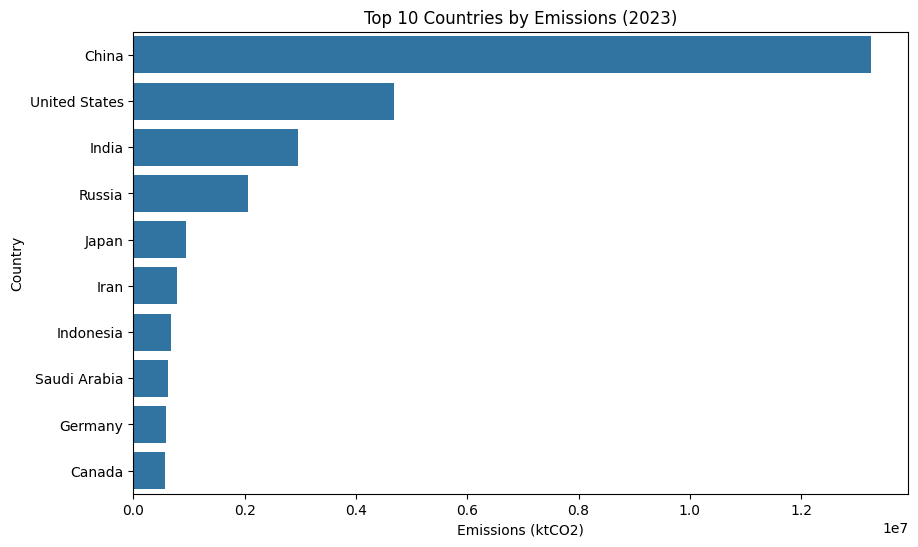

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='Emissions_2023', y='Country')
plt.title('Top 10 Countries by Emissions (2023)')
plt.xlabel('Emissions (ktCO2)')
plt.ylabel('Country')
plt.show

**Comment on Results**

The visualisation of the top 10 emitting countries in 2023 shows a clear concentration of global CO₂ emissions among a small number of major economies. China is by far the largest emitter, significantly exceeding all other countries, followed by the United States and India. This aligns with expectations given their large populations, industrial activity, and energy demand.
There is a noticeable drop in emissions after the top three countries, with nations such as Russia, Japan, and Iran contributing substantially but at much lower levels. Smaller contributors like Indonesia, Saudi Arabia, Germany, and Canada appear in the top 10 but with comparatively limited emissions.
Importantly, aggregated entities such as “Global Total” and “European Union” were removed to ensure a fair country-level comparison, improving the clarity and interpretability of the analysis. The results highlight the uneven distribution of emissions globally and reinforce the importance of focusing climate mitigation efforts on the highest-emitting countries.
(Optional – stronger version for higher marks)
If you want a slightly more analytical version:
The steep drop-off after China and the United States suggests emissions are highly skewed rather than evenly distributed, indicating that targeted policy interventions in a small number of countries could have a disproportionately large global impact

**Data Storage**

In [16]:
# export cleaned dataset to CSV format.
df_clean.to_csv('cleaned_emissions_2023.csv', index=False)

comment: cleaned dataset are exported to csv file to allow reuse, reproducibility, and further analysis outside the notebook

In [17]:
from google.colab import files
files.download('cleaned_emissions_2023.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**6. Analysis and Validation**

In [18]:
df_clean.describe()

,Emissions_2023
count,2.120000e+02
mean,3.799997e+05
std,2.851542e+06
min,2.100000e+00
25%,2.378240e+03
50%,1.205020e+04
75%,6.470280e+04
max,3.902394e+07


**Validation and Analysis**

The descriptive statistics confirm that the dataset is complete and suitable for analysis, with 212 observations and no missing values after cleaning.
The results show that emissions are highly unevenly distributed. The mean (approximately 380,000 ktCO₂) is significantly higher than the median (approximately 12,050 ktCO₂), indicating a strong right-skewed distribution. This suggests that a small number of countries produce disproportionately large amounts of CO₂ emissions.
The maximum value (around 39 million ktCO₂) further highlights the presence of extreme values, corresponding to major emitters such as China and the United States. In contrast, the lower quartiles show that most countries have relatively low emissions.
Overall, these statistics validate the dataset and support the earlier visualisation, confirming that global emissions are concentrated among a few dominant economies.

This project demonstrates how an automated data pipeline can be used to efficiently collect, clean, and analyse climate-related data from web sources. The workflow ensures consistency and reduces manual effort, improving reliability. The pipeline is scalable and can be extended to include additional datasets, such as emissions over time or renewable energy indicators. This makes it useful for ongoing climate monitoring and data-driven decision-making.

The pipeline successfully transformed raw, unstructured web data into a clean and structured dataset suitable for analysis and visualisation.

**Limitations of Total Emissions**
While this analysis focuses on total CO₂ emissions, it does not account for differences in population size. Larger countries such as China and India naturally produce higher total emissions due to their population and economic scale. A more balanced comparison would include emissions per capita, which was not available in the dataset. This highlights a limitation of the analysis and suggests an area for future improvement